Dimensionen der Daten: (46, 8)
Anzahl der Spalten: 8
Form Excel: konisch (Hohlkreis)
Material Excel: Stahl S235
Höhe Excel: 13.55
d_list_eingabe
[0.225, 0.194]
z_list
[0.3, 3.5]
t: 0.004
A Leuchte: 0.5
m Leuchte: 44
z_zusatzmasse_list
[]
A_zusatzmasse_list
[]
m_zusatzmasse_list
[]
hoehe_tuere_list
[1.18]
laenge_tuere_list
[0.3]
breite_tuere_list
[0.08]
eckradius_tuere_list
[0.04]
dicke_verstaerkung_list
[0]
breite_verstaerkung_list
[0]
anzahl_elemente
100

0
z_m: 0.0678
d_m_aussen[i]: 0
z_list[1]: 3.5
z_list: [0.3, 3.5]
d_aussen: [0.225, 0.194]
Fläche: 0.0028054351710722174
Theta: 0
Theta in Grad: 0.0
m_x: 0
m_0x: 0
Flächenträgheitsmoment: 1.7483581168071318e-05

1
z_m: 0.2033
d_m_aussen[i]: 0
z_list[1]: 3.5
z_list: [0.3, 3.5]
d_aussen: [0.225, 0.194]
Fläche: 0.0027889398461454634
Theta: 0
Theta in Grad: 0.0
m_x: 0
m_0x: 0
Flächenträgheitsmoment: 1.717705780751479e-05

2
z_m: 0.3387
d_m_aussen[i]: 0
z_list[1]: 3.5
z_list: [0.3, 3.5]
d_aussen: [0.225, 0.194]
Fläche: 0.002772456694890241

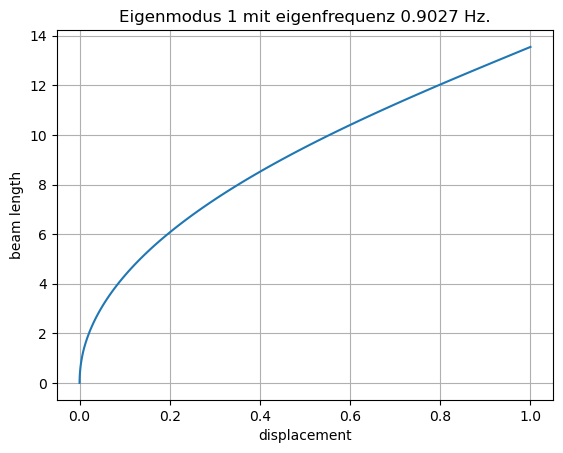

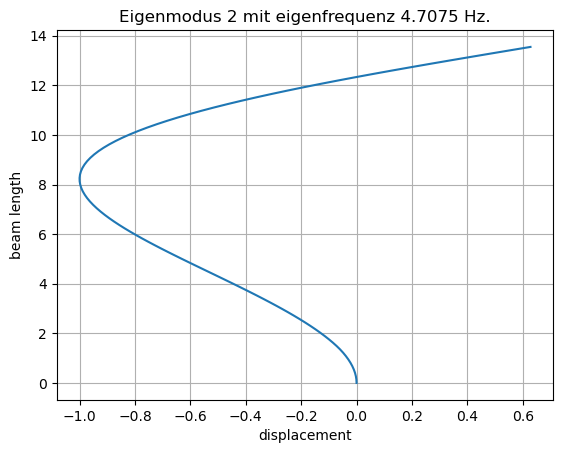

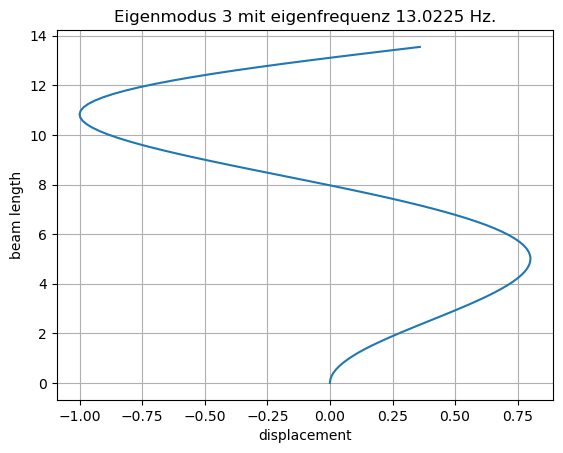

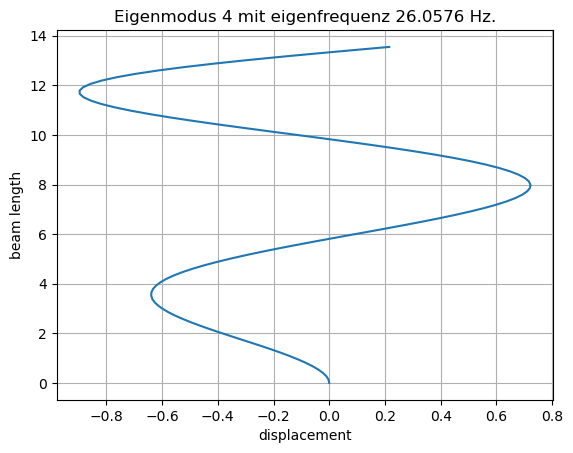

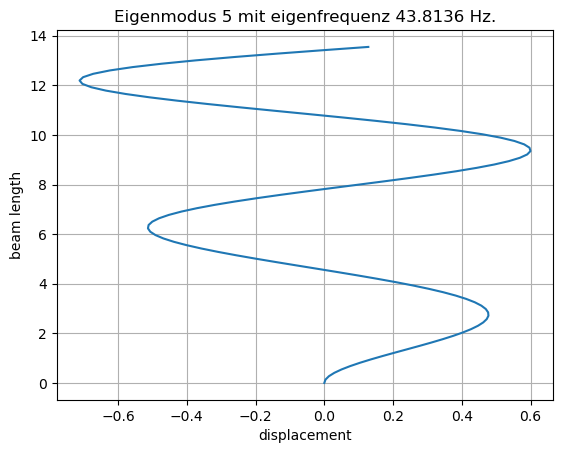

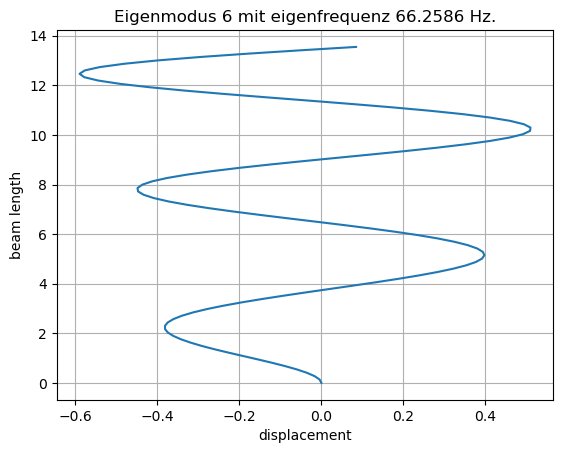

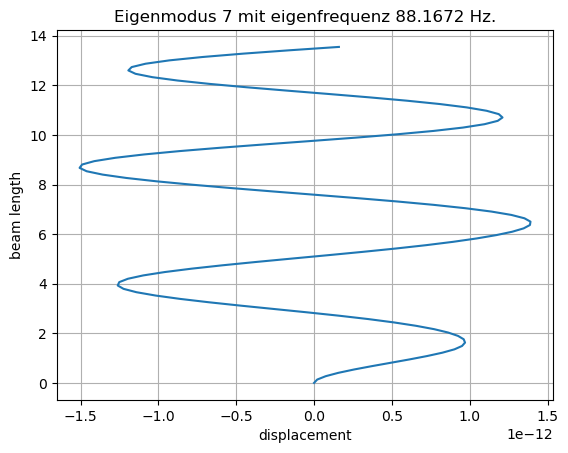

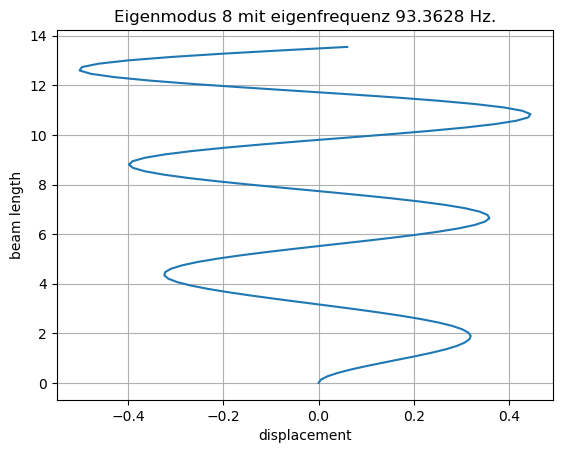

In [1]:
import math
import openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Passe den Dateipfad entsprechend deiner Datei an
dateipfad = "Dateninput_dynamische_analyse.xlsx" # Die Excel Datei muss sich im gleichen Ordner befinden wie die Jupyter Datei


# Einlesen der Excel-Datei
daten = pd.read_excel(dateipfad)

# Anzeigen der Dimension der eingelesenen Daten
print("Dimensionen der Daten:", daten.shape)
anzahl_spalten = daten.shape[1]
print("Anzahl der Spalten:", anzahl_spalten)

#Welche Form hat der Mast? 1 = konisch (Hohlkreis), 2 = konisch (Achteck), 3 = zylindrisch (Hohlkreis)
form_excel = daten.iloc[1,1]
print("Form Excel:" , form_excel)
if form_excel == "konisch (Hohlkreis)":
    form = 1
elif form_excel == "konisch (Achteck)":
    form = 2
elif form_excel == "zylindrisch (Hohlkreis)":
    form = 3
#Aus welchem Material ist der Mast? 1 = Stahl S235, 2 = Stahl S275, 3 = Stahl S355, 4 = Aluminium 6061
material_excel = daten.iloc[3,1]
print("Material Excel:" , material_excel)
if material_excel == "Stahl S235":
    material = 1
elif material_excel == "Stahl S275":
    material = 2
elif material_excel == "Stahl S355":
    material = 3
elif material_excel == "Aluminium 6061":
    material = 4
#Wie hoch ist der Mast [m]?
hoehe_excel = daten.iloc[6,1]
print("Höhe Excel:" , hoehe_excel)
hoehe = hoehe_excel

#für konische Form werden nur 2 Durchmesser/Seitenlängen benötigt. Für zylindrische Form so viele wie man will.
#für zylindrischer Querschnitt: d = Aussendurchmesser [m], für achteckiger Querschnitt: d = Seitenlänge Achteck (aussen) [m]
#In den folgenden Listen kann der Aussendurchmesser/Seitenlänge [m] sowie die Höhe dieses Querschnitts [m] angegeben werden.
d_list_eingabe = []
z_list = []
if form == 1 or form == 2:
    d_list_eingabe_excel1 = daten.iloc[8,1]
    z_list_excel1 = daten.iloc[10,1]
    d_list_eingabe.append(d_list_eingabe_excel1)
    z_list.append(z_list_excel1)
    d_list_eingabe_excel2 = daten.iloc[8,2]
    z_list_excel2 = daten.iloc[10,2]
    d_list_eingabe.append(d_list_eingabe_excel2)
    z_list.append(z_list_excel2)
elif form == 3:
    d_list_eingabe_excel = daten.iloc[8,1]
    anzahl_D = 0
    while pd.notnull(d_list_eingabe_excel):
        z_list_excel = daten.iloc[10,1+anzahl_D]
        anzahl_D += 1
        d_list_eingabe.append(d_list_eingabe_excel)
        z_list.append(z_list_excel)
        if anzahl_D >= anzahl_spalten-1:
            break
        d_list_eingabe_excel = daten.iloc[8,1+anzahl_D]
print("d_list_eingabe")
print(d_list_eingabe)
print("z_list")
print(z_list)

#Dicke der Mastwand [m]:
t_excel = daten.iloc[12,1]
print("t:" , t_excel)
t = t_excel

#input für die Leuchte
#die Höhe der Leuchte ist momentan automatisch die Masthöhe und es gibt nur eine Leuchte
#Fläche der Leuchte [m^2]:
A_leuchte_excel = daten.iloc[15,1]
print("A Leuchte:" , A_leuchte_excel)
A_leuchte = A_leuchte_excel
#Masse der Leuchte [kg]:
m_leuchte_excel = daten.iloc[15,2]
print("m Leuchte:" , m_leuchte_excel)
m_leuchte = m_leuchte_excel

#input für die Zusatzmassen
#Im Folgenden können Sie die Höhe [m], die Masse [kg] und die projizierte Fläche [m^2] von Zusatzmassen in die Listen eingeben.
#Die Einträge an der gleichen Stelle der jeweiligen Listen sollten dabei der gleichen Zusatzmasse entsprechen.
z_zusatzmasse_list = []
A_zusatzmasse_list = []
m_zusatzmasse_list = []
z_zusatzmasse_excel = daten.iloc[19,2]
anzahl_zusatzmassen = 0
while pd.notnull(z_zusatzmasse_excel):
    A_zusatzmasse_excel = daten.iloc[20,2+anzahl_zusatzmassen]
    m_zusatzmasse_excel = daten.iloc[21,2+anzahl_zusatzmassen]
    anzahl_zusatzmassen += 1
    z_zusatzmasse_list.append(z_zusatzmasse_excel)
    A_zusatzmasse_list.append(A_zusatzmasse_excel)
    m_zusatzmasse_list.append(m_zusatzmasse_excel)
    if anzahl_zusatzmassen >= anzahl_spalten-2:
        break
    z_zusatzmasse_excel = daten.iloc[19,2+anzahl_zusatzmassen]
print("z_zusatzmasse_list")
print(z_zusatzmasse_list)
print("A_zusatzmasse_list")
print(A_zusatzmasse_list)
print("m_zusatzmasse_list")
print(m_zusatzmasse_list)

#input für die Abmessungen von Türen/Öffnungen im Mast
tuer_excel = daten.iloc[24,2]
tuer = "Nein" #damit der code auch ohne Öffnung funktioniert
hoehe_tuere_list = []
laenge_tuere_list = []
breite_tuere_list = []
eckradius_tuere_list = []
dicke_verstaerkung_list = []
breite_verstaerkung_list = []
anzahl_tueren = 0
while tuer_excel != "Nein":
    tuer = "Ja"
    hoehe_tuere_excel = daten.iloc[25,2+anzahl_tueren]
    hoehe_tuere_list.append(hoehe_tuere_excel)
    laenge_tuere_excel = daten.iloc[26,2+anzahl_tueren]
    laenge_tuere_list.append(laenge_tuere_excel)
    breite_tuere_excel = daten.iloc[27,2+anzahl_tueren]
    breite_tuere_list.append(breite_tuere_excel)
    eckradius_tuere_excel = daten.iloc[30,2+anzahl_tueren]
    if pd.isnull(eckradius_tuere_excel):
        eckradius_tuere_excel = 0
    eckradius_tuere_list.append(eckradius_tuere_excel)
    if tuer_excel == "Ja (verstärkt Typ 4)":
        dicke_verstaerkung_excel = daten.iloc[28,2+anzahl_tueren]
        breite_verstaerkung_excel = daten.iloc[29,2+anzahl_tueren]
    elif tuer_excel == "Ja (unverstärkt)":
        dicke_verstaerkung_excel = 0
        breite_verstaerkung_excel = 0
    dicke_verstaerkung_list.append(dicke_verstaerkung_excel)
    breite_verstaerkung_list.append(breite_verstaerkung_excel)
    anzahl_tueren += 1
    if anzahl_tueren >= anzahl_spalten-2:
        break
    tuer_excel = daten.iloc[24,2+anzahl_tueren]
print("hoehe_tuere_list")
print(hoehe_tuere_list)
print("laenge_tuere_list")
print(laenge_tuere_list)
print("breite_tuere_list")
print(breite_tuere_list)
print("eckradius_tuere_list")
print(eckradius_tuere_list)
print("dicke_verstaerkung_list")
print(dicke_verstaerkung_list)
print("breite_verstaerkung_list")
print(breite_verstaerkung_list)

#In wie viele Elemente soll der Mast zur Berechnung unterteilt werden: [ganze Zahl]
anzahl_elemente_excel = daten.iloc[45, 1]
anzahl_elemente = anzahl_elemente_excel
print("anzahl_elemente")
print(anzahl_elemente)

#Berechnungen, jeweils in der Mitte eines Elements zwischen zwei "nodes" berechnet.
#Durchmesser wenn achteckiger Querschnitt
d_flanke = [0] * (len(d_list_eingabe))
d_aussen = [0] * (len(d_list_eingabe))
if form == 2:
    for i in range (len(d_list_eingabe)):
        #d_flanke bezeichnet den Flankendurchmesser bei achteckigen Querschnitten
        d_flanke[i] = 0.5 * d_list_eingabe[i] * (1/math.sin(math.pi/8) + 1/math.tan(math.pi/8))
        print("Flankendurchmesser:" , d_flanke[i])
        #d_aussen bezeichnet den Aussendurchmesser bei achteckigen Querschnitten
        d_aussen[i] = d_list_eingabe[i]/(math.sin(math.pi/8))
        print("Aussendurchmesser" , d_aussen[i])
else: #bei kreisförmigen Querschnitten sind d_flanke und d_aussen gleich
    d_flanke = d_list_eingabe.copy()
    d_aussen = d_list_eingabe.copy()

#Materialkennwerte
if material == 1:
    E = 210000*1000000 #in N/m^2
    rho = 7850 #in kg/m^3
elif material == 2:
    E = 210000*1000000 #in N/m^2
    rho = 7850 #in kg/m^3
elif material == 3:
    E = 210000*1000000 #in N/m^2
    rho = 7850 #in kg/m^3 
elif material == 4:
    E = 70000*1000000 #in N/m^2
    rho = 2700 #in kg/m^3

print()
#z_m enthält die Höhe [m] des Mittelpunktes von jedem Element
z_m = [0] * (anzahl_elemente)
#d_m_flanke, Flankendurchmesser, bei kreisförmigen Querschnitten gleich d_m_aussen
d_m_flanke = [0] * (anzahl_elemente)
#d_m_aussen, Aussendurchmesser, bei kreisförmigen Querschnitten gleich d_m_flanke
d_m_aussen = [0] * (anzahl_elemente)
#d_seite_elementmitte, Seitenlänge aussen in der Mitte des Elements, wird nur für achteckige Querschnitte verwendet
d_seite_elementmitte = [0] * (anzahl_elemente)
#A, Querschnittsfläche in der Mitte eines Elements
A = [0] * (anzahl_elemente)
#L, Länge eines Elements
L = hoehe/anzahl_elemente
#teilt die Zusatzmassen dem nächsten node zu, falls die Zusatzmasse genau in der Mitte liegt, wird sie aufgeteilt.
masse_node_liste = [0] * (anzahl_elemente+1)

#r_m_elementmitte, mittlerer Radius des Querschnitts in der Elementmitte
r_m_elementmitte = [0] * (anzahl_elemente)
#theta, halber Türöffnungswinkel gemäss SN-EN 40-3-3
theta = [0] * (anzahl_elemente)
#m_x, Abstand von Achse zur Mastwandmitte, gemäss SN-EN 40-3-3, 5.6.2.3.2
m_x = [0] * (anzahl_elemente)
#m_0x, Abstand von Achse zum Schwerpunkt der Türverstärkung, gemäss SN-EN 40-3-3, 5.6.2.3.2
m_0x = [0] * (anzahl_elemente)
#z_offen, enthält die Höhen der Elemente, an welchen sich eine Tür befindet, ansonsten 0.
z_offen = [0] * (anzahl_elemente)
#breite_tuere_elementmitte, enthält die Breite der Tür, falls keine Tür, dann 0
breite_tuere_elementmitte = [0] * (anzahl_elemente)
#Breite der Verstärkung
breite_verstaerkung_elementmitte = [0] * (anzahl_elemente)
#Dicke der Verstärkung
dicke_verstaerkung_elementmitte = [0] * (anzahl_elemente)

#I, Flächenträgheitsmoment des entsprechenden Querschnitts
I = [0] * (anzahl_elemente)
#Fläche in der Elementmitte für den kompletten Querschnitt, nur für Acheckquerschnitte verwendet
flaeche_ganz_elementmitte = [0] * (anzahl_elemente)
#Schwerpunktverschiebung des Querschnitts durch das Loch, nur für Achteckquerschnitte verwendet, darf nur bei unverstärkten QS in späteren Berechnungen angewendet werden!
schwerpunktverschiebung_elementmitte = [0] * (anzahl_elemente)

#Nun wird für jedes Element die oben definierten Werte ausgerechnet.
for i in range (anzahl_elemente):
    print(i) #Kontrollausgabe ohne Funktion
    z_m[i] = (hoehe/anzahl_elemente)*(i+0.5)
    if i == (anzahl_elemente):
        z_m[i]= hoehe
    z_m[i] = round(z_m[i],4)
    print("z_m:" , z_m[i]) #Kontrollausgabe ohne Funktion
    if form == 3: # form = zylindrisch, d_m_flanke bzw. d_m_aussen werden entsprechend der Höhe bestimmt
        for j in range (len(z_list)):
            if z_list[j] <= z_m[i]:
                d_m_flanke[i] = d_flanke[j]
                d_m_aussen[i] = d_aussen[j]
                d_seite_elementmitte[i] = d_list_eingabe[j]
    if form == 1 or form == 2: # form = konisch, lineare Interpolation
        d_m_flanke[i] = d_flanke[0] - ((d_flanke[0]-d_flanke[1])/(z_list[1]-z_list[0]))*(z_m[i]-z_list[0])
        print("d_m_aussen[i]:", d_m_aussen[i])
        print("z_list[1]:" , z_list[1])
        print("z_list:", z_list)
        print("d_aussen:", d_aussen)
        d_m_aussen[i] = d_aussen[0] - ((d_aussen[0]-d_aussen[1])/(z_list[1]-z_list[0]))*(z_m[i]-z_list[0])
        d_seite_elementmitte[i] = d_list_eingabe[0] - ((d_list_eingabe[0]-d_list_eingabe[1])/(z_list[1]-z_list[0]))*(z_m[i]-z_list[0])
    r_m_elementmitte[i] = (d_m_flanke[i]-t)/2
    if form == 1 or form == 3:
        A[i] = (d_m_aussen[i]**2-(d_m_aussen[i]-2*t)**2)*math.pi/4
    elif form == 2:
        A[i] = 8*t*(d_seite_elementmitte[i]-t/math.tan(3*math.pi/8))
    print("Fläche:" , A[i])

    for k in range (len(z_zusatzmasse_list)): #Falls eine Zusatzmasse gerade in der Mitte eines Elements liegt, wird sie gleichmässig auf die beiden nodes aufgeteilt.
        if i == 0 and z_zusatzmasse_list[k] == 0:
            masse_node_liste[i] += m_zusatzmasse_list[k]
        elif i == anzahl_elemente and z_zusatzmasse_list[k] == hoehe: #damit Zusatzmassen an der Spitze sicher auch berücksichtigt werden
            masse_node_liste[i+1] += m_zusatzmasse_list[k]
        elif z_m[i]-L < z_zusatzmasse_list[k] and z_m[i] > z_zusatzmasse_list[k]:
            masse_node_liste[i] += m_zusatzmasse_list[k]
        elif z_m[i]-L == z_zusatzmasse_list[k] or z_m[i] == z_zusatzmasse_list[k]:
            masse_node_liste[i] += 0.5*m_zusatzmasse_list[k]
            if i == anzahl_elemente: #für den Fall, dass eine Masse auf die beiden obersten nodes aufgeteilt werden muss
                masse_node_liste[i+1] += 0.5*m_zusatzmasse_list[k]
            
    #theta
    if tuer == "Ja" or tuer == "ja":
        for a in range (anzahl_tueren):
            if z_m[i] >= hoehe_tuere_list[a] and z_m[i] <= hoehe_tuere_list[a]+laenge_tuere_list[a]:
                z_offen[i] = z_m[i]
                print("Hier ist eine Tür:" , z_offen[i])
                breite_tuere_elementmitte[i] = breite_tuere_list[a]
                #theta besser noch vor der Unterscheidung der Verstärkung definieren:
                if breite_tuere_list[a]/d_m_flanke[i] > 1:
                    print("die Tür ist zu breit.")
                    break
                if form == 1 or form == 3:
                    theta[i] = math.asin(breite_tuere_list[a]/d_m_flanke[i])          
                elif form == 2:
                    #theta für Achteck:
                    if breite_tuere_list[a] <= d_seite_elementmitte[i]:
                        r_klein = 0.5*d_seite_elementmitte[i]*(1+math.sqrt(2))
                    elif breite_tuere_list[a] > d_seite_elementmitte[i]:
                        r_klein = 0.5*d_seite_elementmitte[i]*(1+math.sqrt(2)) - 0.5*(breite_tuere_list[a]-d_seite_elementmitte[i])
                    theta[i] = math.atan(breite_tuere_list[a]/2/r_klein)
                if dicke_verstaerkung_list[a] != 0:  #überprüft ob es eine verstaerkung hat
                    breite_verstaerkung_elementmitte[i] = breite_verstaerkung_list[a]
                    dicke_verstaerkung_elementmitte[i] = dicke_verstaerkung_list[a]
                    if form == 2:
                        if breite_tuere_list[a] <= d_seite_elementmitte[i]:
                            m_x[i] = 0.5*d_seite_elementmitte[i]*(1+math.sqrt(2)) - 0.5*t
                        elif breite_tuere_list[a] > d_seite_elementmitte[i]:
                            m_x[i] = 0.5*d_seite_elementmitte[i]*(1+math.sqrt(2)) - 0.5*(breite_tuere_list[a]-d_seite_elementmitte[i]) - t/2*math.cos(theta[i])
                        if breite_tuere_list[a] + 2*breite_verstaerkung_list[a] <= d_seite_elementmitte[i]:
                            m_0x[i] = 0.5*d_seite_elementmitte[i]*(1+math.sqrt(2)) - t - 0.5*dicke_verstaerkung_list[a]
                        elif breite_tuere_list[a] <= d_seite_elementmitte[i]:
                            m_0x[i] = 0.5*d_seite_elementmitte[i]*(1+math.sqrt(2)) - (t+0.5*dicke_verstaerkung_list[a])*math.cos(math.pi/8) - 0.5*breite_verstaerkung_list[a]*math.sin(math.pi/8)
                        elif breite_tuere_list[a] > d_seite_elementmitte[i]:
                            m_0x[i] = 0.5*d_seite_elementmitte[i]*(1+math.sqrt(2)) - 0.5*(breite_tuere_list[a]-d_seite_elementmitte[i]) - (t+0.5*dicke_verstaerkung_list[a])*math.cos(theta[i]) - 0.5*breite_verstaerkung_list[a]*math.sin(theta[i])
                    if form == 1 or form == 3:
                        m_x[i] = r_m_elementmitte[i]*math.cos(theta[i])
                        m_0x[i] = m_x[i] - breite_verstaerkung_list[a]*math.sin(theta[i]) - 0.5*(t+dicke_verstaerkung_list[a])*math.cos(theta[i])    
            
        print("Theta:" , theta[i])
        print("Theta in Grad:", theta[i]*180/math.pi)
        print("m_x:" , m_x[i])
        print("m_0x:" , m_0x[i])
             
    #Flächenträgheitsmoment berechnen
    if form == 2: #Achteck
        if theta[i] == 0:
            I[i] = (11+8*math.sqrt(2))/12 * ( (d_seite_elementmitte[i])**4 - (d_seite_elementmitte[i] - 2*t*math.tan(math.pi/8))**4)
            print("D:" , d_seite_elementmitte[i])
        elif theta[i] != 0:
            flaechentraegheitsmoment_ohne_loch = (11+8*math.sqrt(2))/12 * ( (d_seite_elementmitte[i])**4 - (d_seite_elementmitte[i] - 2*t*math.tan(math.pi/8))**4)
            flaeche_ganz_elementmitte[i] = 8*t*(d_seite_elementmitte[i]-t/math.tan(3*math.pi/8))
            if breite_tuere_elementmitte[i] <= d_seite_elementmitte[i]:
                schwerpunktverschiebung_elementmitte[i] = -breite_tuere_elementmitte[i]*t*(d_seite_elementmitte[0]/(2*math.tan(math.pi/8)))/(flaeche_ganz_elementmitte[i] - breite_tuere_elementmitte[i]*t)
                I[i] = flaechentraegheitsmoment_ohne_loch + flaeche_ganz_elementmitte[i]*schwerpunktverschiebung_elementmitte[i]**2 - 1/12*breite_tuere_elementmitte[i]*t**3 - breite_tuere_elementmitte[i]*t*( (d_seite_elementmitte[i]/(2*math.tan(math.pi/8))) -0-5*t - schwerpunktverschiebung_elementmitte[i] )**2
                if breite_verstaerkung_elementmitte[i] != 0:  #überprüft ob es eine verstaerkung hat
                    flaeche_verstaerkung = breite_verstaerkung_elementmitte[i]*dicke_verstaerkung_elementmitte[i]
                    schwerpunktverschiebung_neu = (-breite_tuere_elementmitte[i]*t*(d_seite_elementmitte[0]/(2*math.tan(math.pi/8))) + 2*flaeche_verstaerkung*m_0x[i])/(flaeche_ganz_elementmitte[i] - breite_tuere_elementmitte[i]*t + 2*flaeche_verstaerkung)
                    if breite_tuere_elementmitte[i] + 2*breite_verstaerkung_elementmitte[i] <= d_seite_elementmitte[i]:
                        beitrag1 = 2*(1/12*breite_verstaerkung_elementmitte[i]*dicke_verstaerkung_elementmitte[i]**3 + flaeche_verstaerkung*(m_0x[i]-schwerpunktverschiebung_neu)**2)
                        I[i] += (flaeche_ganz_elementmitte[i]-breite_tuere_elementmitte[i]*t)*(schwerpunktverschiebung_elementmitte[i]-schwerpunktverschiebung_neu)**2 + beitrag1
                    elif breite_tuere_elementmitte[i] + 2*breite_verstaerkung_elementmitte[i] > d_seite_elementmitte[i]:
                        beitrag1 = 2*( 0.5*1/12*breite_verstaerkung_elementmitte[i]*dicke_verstaerkung_elementmitte[i]**3 + 0.5*1/12*dicke_verstaerkung_elementmitte[i]*breite_verstaerkung_elementmitte[i]**2 + flaeche_verstaerkung*(m_0x[i]-schwerpunktverschiebung_neu)**2 )
                        I[i] += (flaeche_ganz_elementmitte[i]-breite_tuere_elementmitte[i]*t)*(schwerpunktverschiebung_elementmitte[i]-schwerpunktverschiebung_neu)**2 + beitrag1
            elif breite_tuere_elementmitte[i] > d_seite_elementmitte[i]:
                #die Berechnung enthält leichte Vereinfachungen: der Schwerpunkt der Stirnfläche, welche nun aufgrund der Öffnung nicht mehr im Querschnitt enthalten ist, wurde in der Mitte der Dicke angenommen, die seitlichen Komponenten, welche nun nicht mehr vorhanden sind, wurden als Rechteck behandelt.
                r_klein = d_seite_elementmitte[i]/(2*math.tan(math.pi/8))
                breite_tuer = breite_tuere_elementmitte[i]
                flaechenabzug1 = t*(d_seite_elementmitte[i]-t/(math.tan(3*math.pi/8)))
                flaechenabzug2 = math.sqrt(2)/2*(breite_tuere_elementmitte[i]-d_seite_elementmitte[i])*t
                flaechenabzug = flaechenabzug1 + 2*flaechenabzug2
                schwerpunktverschiebung_elementmitte[i] = (-flaechenabzug1*(r_klein-0.5*t)-2*flaechenabzug2*(r_klein-0.5*t-0.5*0.5*(breite_tuer-d_seite_elementmitte[i])))/(flaeche_ganz_elementmitte[i]-flaechenabzug)
                beitrag1 = 1/12*d_seite_elementmitte[i]*t**3 + flaechenabzug1*(r_klein-0.5*t-schwerpunktverschiebung_elementmitte[i])**2
                beitrag2 = 2*( 0.5*1/12*math.sqrt(2)/2*(breite_tuer-d_seite_elementmitte[i]) *t**3 + 0.5*1/12*t * (math.sqrt(2)/2*(breite_tuer-d_seite_elementmitte[i]))**3 + flaechenabzug2*( r_klein-0.5*t-0.5*0.5*(breite_tuer-d_seite_elementmitte[i])-schwerpunktverschiebung_elementmitte[i])**2 )
                I[i] = flaechentraegheitsmoment_ohne_loch + flaeche_ganz_elementmitte[i]*schwerpunktverschiebung_elementmitte[i]**2 - beitrag1 - beitrag2
                if breite_verstaerkung_elementmitte[i] != 0:  #überprüft ob es eine verstaerkung hat
                    flaeche_verstaerkung = breite_verstaerkung_elementmitte[i]*dicke_verstaerkung_elementmitte[i]
                    schwerpunktverschiebung_neu = (-flaechenabzug1*(r_klein-0.5*t)-2*flaechenabzug2*(r_klein-0.5*t-0.5*0.5*(breite_tuer-d_seite_elementmitte[i])) + 2*flaeche_verstaerkung*m_0x[i])/( flaeche_ganz_elementmitte[i]-flaechenabzug+2*flaeche_verstaerkung )
                    beitrag1 = 2*( 0.5*1/12*breite_verstaerkung_elementmitte[i]*dicke_verstaerkung_elementmitte[i]**3 + 0.5*1/12*dicke_verstaerkung_elementmitte[i]*breite_verstaerkung_elementmitte[i]**2 + flaeche_verstaerkung*(m_0x[i]-schwerpunktverschiebung_neu)**2 )
                    I[i] += (flaeche_ganz_elementmitte[i]-flaechenabzug)*(schwerpunktverschiebung_elementmitte[i]-schwerpunktverschiebung_neu)**2 + beitrag1
    elif form == 1 or form == 3: #kreisförmiger Querschnitt
        if theta[i] == 0:
            I[i] = math.pi/4* ( (r_m_elementmitte[i]+(t/2))**4 - (r_m_elementmitte[i]-(t/2))**4 )
        elif theta[i] != 0:
            r_aussen = r_m_elementmitte[i]+(t/2)
            r_innen = r_m_elementmitte[i]-(t/2)
            I[i] = 1/4*(r_aussen**4-r_innen**4)*(math.pi - theta[i] - math.sin(theta[i])*math.cos(theta[i]) ) + 4/9*(r_aussen**3 - r_innen**3)**2 * math.sin(theta[i])*math.sin(theta[i])* 1/( (r_aussen**2 - r_innen**2)*(math.pi-theta[i])  )
            if breite_verstaerkung_elementmitte[i] != 0: #überprüft ob es eine verstaerkung hat
                flaeche_verstaerkung = breite_verstaerkung_elementmitte[i]*dicke_verstaerkung_elementmitte[i]
                #die folgende Verschiebung berechnet den Abstand vom Schwerpunkt zur x-Achse und nicht die reine Verschiebung des Schwerpunkts durch die Verstärkung.
                schwerpunktverschiebung_elementmitte[i] = (2*flaeche_verstaerkung*m_0x[i] - (2/3*(r_aussen**3 - r_innen**3) * math.sin(theta[i])) ) /(2*flaeche_verstaerkung + (r_aussen**2 - r_innen**2)*(math.pi-theta[i]) )
                beitrag1 = 2*( 1/12*dicke_verstaerkung_elementmitte[i]**3 *breite_verstaerkung_elementmitte[i] *math.cos(theta[i])*math.cos(theta[i]) + 1/12*breite_verstaerkung_elementmitte[i]**3 *dicke_verstaerkung_elementmitte[i] *math.sin(theta[i])*math.sin(theta[i]) + flaeche_verstaerkung*(m_0x[i]-schwerpunktverschiebung_elementmitte[i])**2)
                beitrag2 = (math.pi-theta[i])*(r_aussen**2 - r_innen**2)* (-2/3*(r_aussen**3 - r_innen**3)*math.sin(theta[i])/((r_aussen**2 - r_innen**2)*(math.pi-theta[i]))   + schwerpunktverschiebung_elementmitte[i] )**2
                I[i] += beitrag2 - beitrag1
    print("Flächenträgheitsmoment:" , I[i])
    
    print()
print("fertig mit Tabelle 1")
print()

#Jetzt Matrizen
anzahl_nodes = anzahl_elemente + 1
anzahl_dof = 3*anzahl_nodes
k_matrix_1 = np.zeros( (anzahl_dof,anzahl_dof) )
m_matrix_1 = np.zeros( (anzahl_dof,anzahl_dof) )
print("Kontrolle1:" , E*A[0]/L)
print("Kontrolle2:" , I[0])
print("Kontrolle3:" , 12*E*I[0]/(L**3)) 
print("Kontrolle4:" , I)
for i in range (anzahl_elemente):
    k_1a = np.array( [ [E*A[i]/L, 0, 0],
                     [0, 12*E*I[i]/(L**3), 6*E*I[i]/(L**2)],
                     [0, 6*E*I[i]/(L**2), 4*E*I[i]/L] ] )
    k_1b = np.array( [ [-E*A[i]/L, 0, 0],
                     [0, -12*E*I[i]/(L**3), 6*E*I[i]/(L**2)],
                     [0, -6*E*I[i]/(L**2), 2*E*I[i]/L] ] )
    k_1c = np.array( [ [-E*A[i]/L, 0, 0],
                     [0, -12*E*I[i]/(L**3), -6*E*I[i]/(L**2)],
                     [0, 6*E*I[i]/(L**2), 2*E*I[i]/L] ] )
    k_1d = np.array( [ [E*A[i]/L, 0, 0],
                     [0, 12*E*I[i]/(L**3), -6*E*I[i]/(L**2)],
                     [0, -6*E*I[i]/(L**2), 4*E*I[i]/L] ] )
    
    k_matrix_3_dof = np.array( [ [k_1a[0][0], k_1a[0][1], k_1a[0][2], k_1b[0][0], k_1b[0][1], k_1b[0][2] ],
                                 [k_1a[1][0], k_1a[1][1], k_1a[1][2], k_1b[1][0], k_1b[1][1], k_1b[1][2] ],
                                 [k_1a[2][0], k_1a[2][1], k_1a[2][2], k_1b[2][0], k_1b[2][1], k_1b[2][2] ],
                                 [k_1c[0][0], k_1c[0][1], k_1c[0][2], k_1d[0][0], k_1d[0][1], k_1d[0][2] ],
                                 [k_1c[1][0], k_1c[1][1], k_1c[1][2], k_1d[1][0], k_1d[1][1], k_1d[1][2] ],
                                 [k_1c[2][0], k_1c[2][1], k_1c[2][2], k_1d[2][0], k_1d[2][1], k_1d[2][2] ] ] )
    
    m_1a = np.array( [ [1/3*rho*A[i]*L, 0, 0],
                     [0, 13/35*rho*A[i]*L, 11*L/210*rho*A[i]*L],
                     [0, 11*L/210*rho*A[i]*L, L**2/105*rho*A[i]*L] ] )
    m_1b = np.array( [ [1/6*rho*A[i]*L, 0, 0],
                     [0, 9/70*rho*A[i]*L, -13*L/420*rho*A[i]*L],
                     [0, 13*L/420*rho*A[i]*L, -L**2/140*rho*A[i]*L] ] )
    m_1c = np.array( [ [1/6*rho*A[i]*L, 0, 0],
                     [0, 9/70*rho*A[i]*L, 13*L/420*rho*A[i]*L],
                     [0, -13*L/420*rho*A[i]*L, -L**2/140*rho*A[i]*L] ] )
    m_1d = np.array( [ [1/3*rho*A[i]*L, 0, 0],
                     [0, 13/35*rho*A[i]*L, -11*L/210*rho*A[i]*L],
                     [0, -11*L/210*rho*A[i]*L, L**2/105*rho*A[i]*L] ] )

    m_matrix_3_dof = np.array( [ [m_1a[0][0], m_1a[0][1], m_1a[0][2], m_1b[0][0], m_1b[0][1], m_1b[0][2] ],
                                 [m_1a[1][0], m_1a[1][1], m_1a[1][2], m_1b[1][0], m_1b[1][1], m_1b[1][2] ],
                                 [m_1a[2][0], m_1a[2][1], m_1a[2][2], m_1b[2][0], m_1b[2][1], m_1b[2][2] ],
                                 [m_1c[0][0], m_1c[0][1], m_1c[0][2], m_1d[0][0], m_1d[0][1], m_1d[0][2] ],
                                 [m_1c[1][0], m_1c[1][1], m_1c[1][2], m_1d[1][0], m_1d[1][1], m_1d[1][2] ],
                                 [m_1c[2][0], m_1c[2][1], m_1c[2][2], m_1d[2][0], m_1d[2][1], m_1d[2][2] ] ] )
    
    for j in range (6):
        for q in range (6):
            k_matrix_1[3*i+j][3*i+q] += k_matrix_3_dof[j][q]
            m_matrix_1[3*i+j][3*i+q] += m_matrix_3_dof[j][q]
print("k matrix_1 ohne Randbedingungen:")
print(k_matrix_1)
print("m matrix_1 ohne Randbedingungen:")
print(m_matrix_1)

#Zusatzmassen und Leuchte an der Spitze hinzufügen
#Kyriakos fragen wie das geht, im Moment: m für x und y dof addieren, aber nicht für phi 
#Zusatzmassen
print("Extramassen:" , masse_node_liste)
for i in range (anzahl_nodes):
    m_matrix_1[3*i][3*i] += masse_node_liste[i]
    m_matrix_1[3*i+1][3*i+1] += masse_node_liste[i]
#Leuchte
m_matrix_1[anzahl_dof-3][anzahl_dof-3] += m_leuchte
m_matrix_1[anzahl_dof-2][anzahl_dof-2] += m_leuchte

#Rotationssteifigkeit der "Einspannung" im Boden modellieren
#im Moment muss der entsprechende Wert hier eingegeben werden
#k_matrix_1[2][2] += 1


#dofs, die durch einspannung gehalten werden, löschen
dof_gehalten = [0,1,2]
anzahl_dof_gehalten = len(dof_gehalten)
m_matrix = np.zeros( (anzahl_dof-anzahl_dof_gehalten,anzahl_dof-anzahl_dof_gehalten) )
k_matrix = np.zeros( (anzahl_dof-anzahl_dof_gehalten,anzahl_dof-anzahl_dof_gehalten) )
a = 0
for i in range (anzahl_dof):
    b = 0
    if i not in dof_gehalten:
        for j in range (anzahl_dof):
            if j not in dof_gehalten:
                m_matrix[a][b]  = m_matrix_1[i][j]
                k_matrix[a][b]  = k_matrix_1[i][j]
                b += 1
        a += 1
print("k_matrix mit Randbedingungen:")
print(k_matrix)
print("m_matrix mit Randbedingungen:")
print(m_matrix)

#Eigenfrequenzen und -modi berechnen
D, V = np.linalg.eig(np.dot(np.linalg.inv(m_matrix), k_matrix))
#D = eigenwerte, V = eigenvektoren
print("D:" , D)
print("V:" , V) #eigenmodi sind Spalten in der V-matrix
sortiert_D = sorted(D)
print("sortiert_D:")
print(sortiert_D)
transponiert_V = np.transpose(V) #jetzt sind die eigenmodi Zeilen in der transponierten V-matrix
print("transponiert_V:")
print(transponiert_V)
sortiert_V = np.zeros( (len(D),len(D)) )
for i in range (len(D)):
    for j in range (len(D)):
        if sortiert_D[i] == D[j]:
            sortiert_V[i] = transponiert_V[j]
print("sortiert_V:")
print(sortiert_V)
normalisiert_V = np.zeros( (len(D),len(D)) )
for i in range (len(D)):
    max_verschiebung = max(sortiert_V[i], key=abs)
    if max_verschiebung != 0:
        ratio = 1/max_verschiebung
        ratio = abs(ratio)
        normalisiert_V[i] = [x*ratio for x in sortiert_V[i]]
    else:
        normalisiert_V[i] = sortiert_V[i]
print("normalisiert_V:")
print(normalisiert_V)
eigenfrequenzen = sortiert_D
eigenfrequenzen = [math.sqrt(x)/(2*math.pi) for x in eigenfrequenzen]
print("Eigenfrequenzen:")
print(eigenfrequenzen)

#die gehaltenen dof zu den Eigenmodi hinzufügen
normalisiert_V_gross = np.zeros( (len(D),anzahl_dof) )
for i in range (len(D)):
    a = 0
    for j in range (anzahl_dof):
        if j in dof_gehalten:
            normalisiert_V_gross[i][j] = 0
            a += 1
        else:
            normalisiert_V_gross[i][j] = normalisiert_V[i][j-a]
print("normalisiert_V_gross:")
print(normalisiert_V_gross)

#Eigenmodi plotten
beam_length = []
for i in range(anzahl_nodes):
    beam_length.append(L*i)
displacement = np.zeros( (len(D),anzahl_nodes) )
for i in range (len(D)):
    for j in range (anzahl_nodes):
        displacement[i][j] = normalisiert_V_gross[i][3*j+1]
print("displacement")
print(displacement)

##for i in range (len(D)):
for i in range(8): #Jetzt werden nur die ersten 8 geplottet.
    plt.plot(displacement[i],beam_length)
    plt.xlabel('displacement')
    plt.ylabel('beam length')
    str_i = str(i+1)
    str_eigenfrequenzen = str(round(eigenfrequenzen[i],4))
    plt.title('Eigenmodus ' + str_i + ' mit eigenfrequenz ' + str_eigenfrequenzen + ' Hz.')
    plt.grid(True)  # Add grid
    plt.show()